# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [ ]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [ ]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [ ]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [7]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [8]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [ ]:
La diferencia fundamental entre ambas técnicas reside en la representación matemática y la jerarquía de los datos. El LabelEncoder condensa todas las categorías en una sola columna asignando a cada una un número entero (0, 1, 2...), lo cual es eficiente en espacio pero tiene el riesgo de que el modelo interprete un orden de importancia o magnitud inexistente entre los valores; por ello, su uso se limita a variables ordinales donde el orden sí importa. Por el contrario, el OneHotEncoder expande cada categoría en columnas binarias independientes (0 o 1), asegurando que el algoritmo trate a todos los valores con la misma relevancia y sin jerarquías artificiales, lo que lo convierte en la opción ideal para variables nominales, a pesar de que incrementa la dimensionalidad del conjunto de datos.

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

C:\Users\PC FACTOR BLACK\AppData\Local\Temp\ipykernel_91500\2185900631.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=data, ax=axes[0], palette='pastel')
C:\Users\PC FACTOR BLACK\AppData\Local\Temp\ipykernel_91500\2185900631.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex_label', data=data, ax=axes[1], palette='magma')


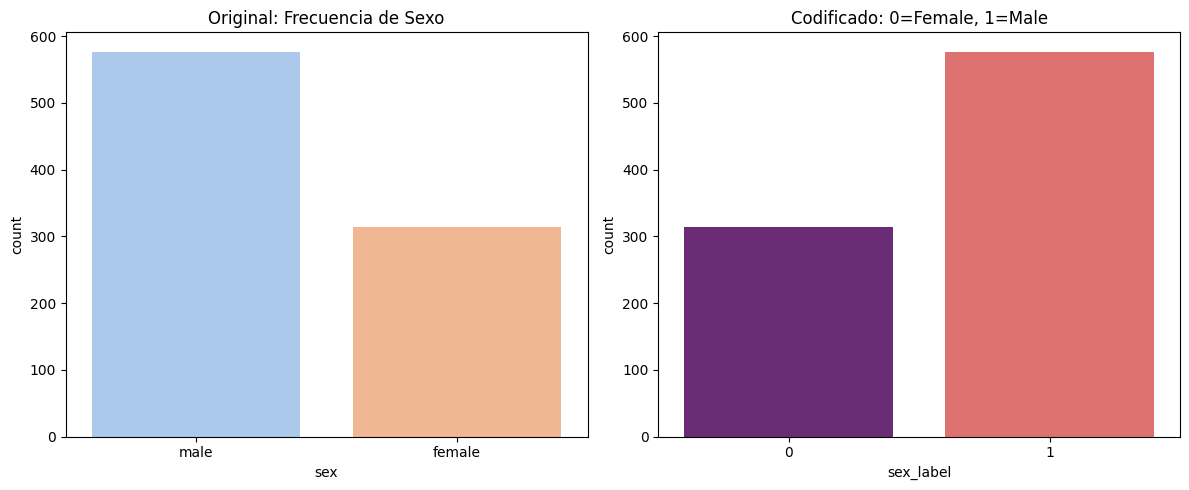

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. Cargamos el conjunto de datos Titanic
data = sns.load_dataset('titanic')

# 2.Aplicamos el LabelEncoder para asegurar que exista 'sex_label'
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

# 3. Generamos las gráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes de codificar
sns.countplot(x='sex', data=data, ax=axes[0], palette='pastel')
axes[0].set_title('Original: Frecuencia de Sexo')

# Después de codificar (LabelEncoder)
sns.countplot(x='sex_label', data=data, ax=axes[1], palette='magma')
axes[1].set_title('Codificado: 0=Female, 1=Male')

plt.tight_layout() # Esto ayuda a que los títulos no se encimen
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [3]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Instanciamos el codificador
# Usamos sparse_output=False para que nos devuelva una matriz tradicional fácil de leer
encoder_onehot = OneHotEncoder(sparse_output=False)

# 2. Ajustamos y transformamos la columna 'class'
# Nota: Pasamos [['class']] con doble corchete porque espera datos bidimensionales
class_encoded = encoder_onehot.fit_transform(data[['class']])

# 3. Lo convertimos a un DataFrame para visualizarlo correctamente
columnas_nuevas = encoder_onehot.get_feature_names_out(['class'])
df_class_encoded = pd.DataFrame(class_encoded, columns=columnas_nuevas)

# Mostramos las primeras 5 filas para demostrar el resultado
print(df_class_encoded.head())

   class_First  class_Second  class_Third
0          0.0           0.0          1.0
1          1.0           0.0          0.0
2          0.0           0.0          1.0
3          1.0           0.0          0.0
4          0.0           0.0          1.0


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
Si la variable tiene una jerarquía clara, elegiría LabelEncoder (o OrdinalEncoder). Por ejemplo, si estuviera analizando niveles de riesgo en ciberseguridad ('Bajo', 'Medio', 'Alto'), asignarles 0, 1 y 2 es útil porque el incremento numérico sí refleja un incremento real en el nivel de amenaza.